In [49]:

import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

# Load dataset
df = pd.read_csv('q2_customers.csv')
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)
df_scaled = pd.DataFrame(X_scaled, columns=df.columns)
# Result: X_scaled.shape → (500, 6)
# All features: mean ≈ 0.0, std ≈ 1.0 ✓
for col in df.columns:
    print(f"{col} | min: {df[col].min()} | max: {df[col].max()} | std: {df[col].std()}")



age | min: 18 | max: 69 | std: 14.426640354005073
annual_spend | min: 5038 | max: 119757 | std: 32856.7953529712
visits_per_month | min: 1 | max: 19 | std: 5.3245945022345555
basket_size | min: 212 | max: 7981 | std: 2274.957338938905
days_since_last_visit | min: 0 | max: 179 | std: 49.699143390076806
num_categories_purchased | min: 1 | max: 9 | std: 2.4382218626908028


How K-Means Measures Distance

K-Means assigns customers to clusters based on Euclidean distance — whichever centroid a customer is closest to, that's their cluster. The problem? Features with bigger numbers automatically create bigger distances, even if they're no more important than smaller-scale features.
The Problem with Our Data:
age | min: 18 | max: 69 | std: 14.426640354005073
annual_spend | min: 5038 | max: 119757 | std: 32856.7953529712
visits_per_month | min: 1 | max: 19 | std: 5.3245945022345555
basket_size | min: 212 | max: 7981 | std: 2274.957338938905
days_since_last_visit | min: 0 | max: 179 | std: 49.699143390076806
num_categories_purchased | min: 1 | max: 9 | std: 2.4382218626908028

annual_spend has a std dev 13,000× larger than num_categories_purchased. Without scaling, K-Means will cluster customers almost entirely based on spend — completely ignoring visit frequency, recency, and purchasing breadth.

The Fix: StandardScaler

StandardScaler transforms every feature using:

$$z = \frac{x - \mu}{\sigma}$$

This centres each feature at mean = 0 and rescales it to std = 1, so every feature contributes equally to the distance calculation.
Before vs. After Scaling
                              Without Scaling                                 With Scaling

Distance driven by           annual_spend alone                             All 6 features equally
Clusters reflect             Spend magnitude                                True customer behaviour
Result                       Misleading segments                            Meaningful segments

Key Takeaway: Scaling is a mandatory pre-step for K-Means. It ensures no single feature dominates just because its numbers happen to be larger.


K           WCSS       Drop     Drop %
----------------------------------------
1        3000.00        N/A        N/A
2         968.99    2031.01      67.7%
3         561.25     407.74      42.1%
4         444.93     116.32      20.7%
5         402.37      42.56       9.6%
6         370.39      31.98       7.9%
7         346.95      23.44       6.3%
8         319.90      27.05       7.8%
9         303.28      16.62       5.2%
10        289.11      14.17       4.7%


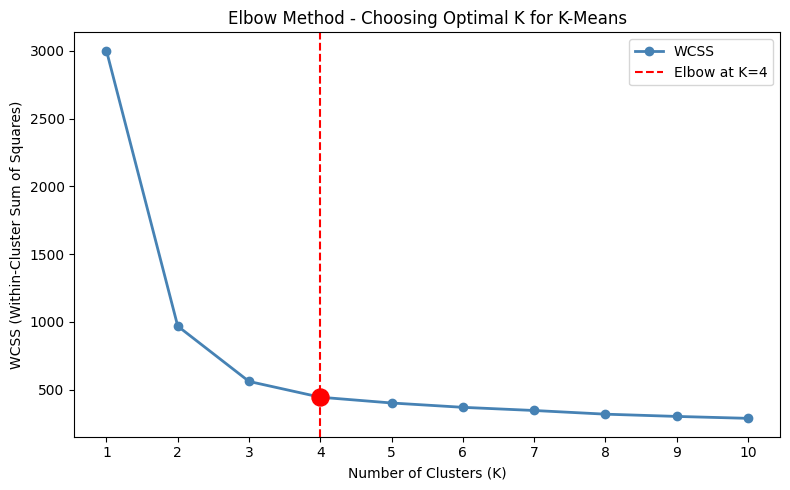

Done! Optimal K = 4


In [50]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Load and Scale
df = pd.read_csv('q2_customers.csv')
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

# Compute WCSS for K = 1 to 10
k_values = list(range(1, 11))
wcss = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(round(kmeans.inertia_, 2))

# Print WCSS Table
print(f"{'K':<5} {'WCSS':>10} {'Drop':>10} {'Drop %':>10}")
print("-" * 40)
for i in range(len(k_values)):
    if i == 0:
        print(f"{k_values[i]:<5} {wcss[i]:>10.2f} {'N/A':>10} {'N/A':>10}")
    else:
        drop = wcss[i-1] - wcss[i]
        drop_pct = (drop / wcss[i-1]) * 100
        print(f"{k_values[i]:<5} {wcss[i]:>10.2f} {drop:>10.2f} {drop_pct:>9.1f}%")

# Plot Elbow Curve
elbow_k = 4
elbow_wcss = wcss[elbow_k - 1]

plt.figure(figsize=(8, 5))
plt.plot(k_values, wcss, marker='o', color='steelblue', linewidth=2, label='WCSS')
plt.axvline(x=elbow_k, color='red', linestyle='--', label='Elbow at K=4')
plt.scatter([elbow_k], [elbow_wcss], color='red', s=150, zorder=5)
plt.title('Elbow Method - Choosing Optimal K for K-Means')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS (Within-Cluster Sum of Squares)')
plt.xticks(k_values)
plt.legend()
plt.tight_layout()
plt.show()

print("Done! Optimal K =", elbow_k)



In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Load and Scale
df = pd.read_csv('q2_customers.csv')
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

# Fit K-Means with K=4
kmeans = KMeans(n_clusters=4, init='k-means++', n_init=10, random_state=42)
kmeans.fit(X_scaled)

# Add cluster column
df['Cluster'] = kmeans.labels_

# Centroids in original scale
centroids_original = scaler.inverse_transform(kmeans.cluster_centers_)
centroids_df = pd.DataFrame(centroids_original, columns=df.columns[:-1])
centroids_df.index = [f'Cluster {i}' for i in range(4)]
centroids_df.index.name = 'Cluster'

# Fix: set pandas to show ALL columns with no truncation
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

print("=== Cluster Distribution ===")
print(df['Cluster'].value_counts().sort_index())

# Fix: Print TRANSPOSED — features as rows, clusters as columns
print("=== Cluster Centroids (Original Scale) ===")
print(centroids_df.round(2).T)




=== Cluster Distribution ===
Cluster
0    170
1     80
2    165
3     85
Name: count, dtype: int64
=== Cluster Centroids (Original Scale) ===
Cluster                   Cluster 0  Cluster 1  Cluster 2  Cluster 3
age                           24.68      57.04      40.39      56.52
annual_spend               14847.37   89814.07   43340.73   89036.16
visits_per_month              14.34       2.46       8.19       2.59
basket_size                  558.97    5296.36    2021.68    5750.95
days_since_last_visit          9.08     148.00      35.19      65.22
num_categories_purchased       2.11       7.49       4.42       7.54


Markdown Explanation — Business Interpretation of Each Cluster:

What Do the Clusters Actually Mean?
After running K-Means with K=4, each customer has been assigned to one of four groups. By looking at the centroid values (the average profile of each cluster), we can give each group a meaningful business label.
Cluster 0 — "Young Frequent Budget Shoppers" (170 customers)

Young customers (~25 years old) who visit very frequently (14x/month) but spend very little (£14,847/year) with tiny basket sizes (£559) and only 2 categories purchased. They are active but low-value shoppers.

Business Interpretation: These are young, highly active customers who visit very frequently but spend very little per trip. They buy from only 1–2 categories and have small basket sizes. They are likely browsing or buying essentials rather than making big purchases.

0. Business Action: Target with loyalty rewards and upselling campaigns to increase basket size and category breadth.

Cluster 1 — "Lapsed High-Value Seniors" (80 customers)

Older customers (~57 years old) with high annual spend (£89,814) and large baskets (£5,296) across 7–8 categories, but they have not visited in ~148 days. They are high-value customers at serious risk of churning.

Business Interpretation: These are older, high-spending customers who used to buy across many categories but have not visited in nearly 5 months. They are at serious risk of churning despite their high value.

1. Business Action: Urgent win-back campaigns — personalised offers, loyalty incentives, or direct outreach to re-engage before they are lost permanently.

Cluster 2 — "Mid-Range Regular Shoppers" (165 customers)

Middle-aged customers (~40 years old) with moderate spend (£43,341), average visit frequency (8x/month), and a basket size of £2,022 across 4 categories. They are the most consistent and stable segment.

Business Interpretation: These are middle-aged, moderately engaged customers with average spending and visit frequency. They are the backbone of the business — consistent, reliable, and spread across multiple categories.

2. Business Action: Nurture with personalised recommendations and cross-category promotions to move them toward higher-value behaviour.

Cluster 3 — "Active High-Value Seniors" (85 customers)

Older customers (~57 years old) with high spend (£89,036), the largest basket sizes (£5,751), and 7–8 categories purchased. Unlike Cluster 1, they are still actively shopping (last visit ~65 days ago) making them the most valuable active segment.

Business Interpretation: Similar age and spend to Cluster 1, but these customers are still engaged — they visited within the last 2 months and have the largest basket sizes of all groups. They are the most valuable active customers.

3. Business Action: Protect and reward with VIP programmes, exclusive previews, and premium service to maintain their loyalty.

Key Take Away: K-Means has revealed four distinct customer personas. Clusters 1 and 3 are both high-value older customers — the critical difference is recency: Cluster 3 is still active (65 days) while Cluster 1 is nearly lost (148 days). This distinction alone makes the segmentation highly actionable for the business.

In [52]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Load and Scale
df = pd.read_csv('q2_customers.csv')
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

# Apply PCA — reduce to 2 principal components
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Print Explained Variance Ratio
print("=== Explained Variance Ratio ===")
for i, var in enumerate(pca.explained_variance_ratio_):
    print(f"PC{i+1}: {var:.4f} ({var*100:.2f}%)")
print(f"Total Variance Explained: {sum(pca.explained_variance_ratio_)*100:.2f}%")

# Print Feature Loadings
loadings_df = pd.DataFrame(
    pca.components_.T,
    index=df.columns,
    columns=['PC1', 'PC2']
)
print("=== Feature Loadings (PCA Components) ===")
print(loadings_df.round(4))

print(f"Original Shape : {X_scaled.shape}")
print(f"Reduced Shape  : {X_pca.shape}")

=== Explained Variance Ratio ===
PC1: 0.8356 (83.56%)
PC2: 0.0557 (5.57%)
Total Variance Explained: 89.13%
=== Feature Loadings (PCA Components) ===
                             PC1     PC2
age                       0.4116 -0.2594
annual_spend              0.4215 -0.0333
visits_per_month         -0.4104  0.2083
basket_size               0.4120 -0.1954
days_since_last_visit     0.3786  0.9112
num_categories_purchased  0.4140 -0.1405
Original Shape : (500, 6)
Reduced Shape  : (500, 2)


What Do PC1 and PC2 Capture?
PC1 — "Overall Customer Value" (83.56% of variance)

PC1 is driven almost equally by all six features. Features like annual_spend (+0.42), basket_size (+0.41), age (+0.41), and num_categories_purchased (+0.41) all load positively, while visits_per_month loads negatively (−0.41). This means PC1 separates high-value, infrequent shoppers (older, high spend, large baskets) from low-value, frequent shoppers (younger, low spend, small baskets). It captures the overall spending power of a customer.

PC2 — "Customer Recency" (5.57% of variance)

PC2 is almost entirely dominated by days_since_last_visit (+0.91), with all other features contributing very little. This means PC2 simply captures how recently a customer last visited — a high PC2 score means the customer has been absent for a long time (lapsed), while a low score means they visited recently (active).

Total Variance Explained: 89.13%

Together, PC1 and PC2 retain 89.13% of the information from the original 6 features, meaning very little is lost by reducing to just 2 dimensions. This makes PCA an effective tool for visualising customer clusters without losing meaningful patterns.



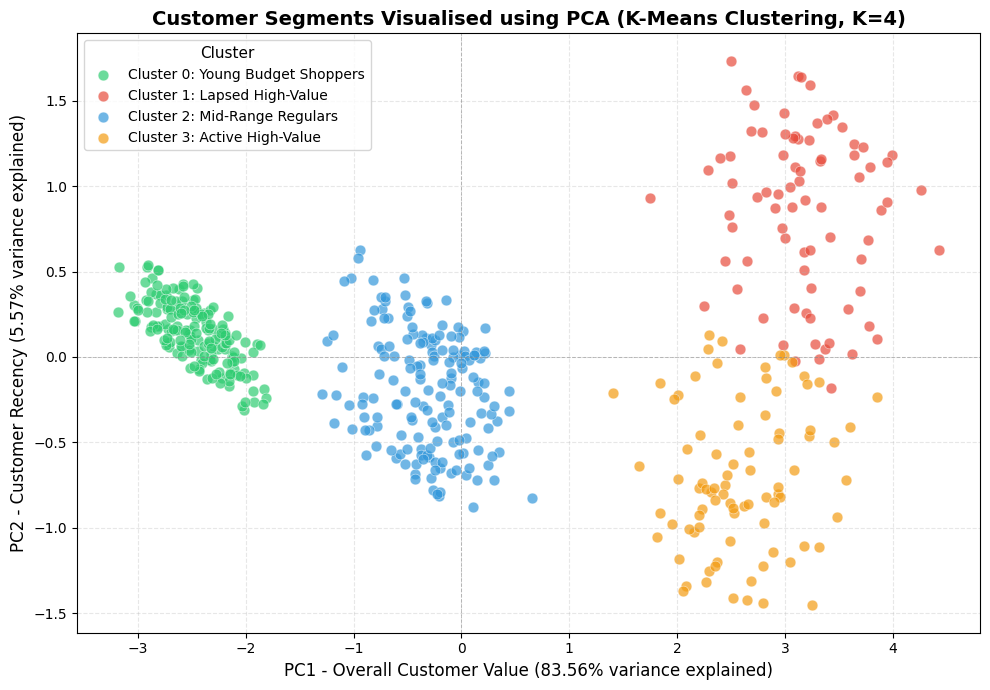

Done!


In [56]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Load and Scale
df = pd.read_csv('q2_customers.csv')
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

# Fit K-Means with K=4
kmeans = KMeans(n_clusters=4, init='k-means++', n_init=10, random_state=42)
kmeans.fit(X_scaled)
df['Cluster'] = kmeans.labels_

# Apply PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Define colours and labels
colors = ['#2ecc71', '#e74c3c', '#3498db', '#f39c12']
cluster_labels = [
    'Cluster 0: Young Budget Shoppers',
    'Cluster 1: Lapsed High-Value',
    'Cluster 2: Mid-Range Regulars',
    'Cluster 3: Active High-Value'
]

# Scatter plot
plt.figure(figsize=(10, 7))

for i in range(4):
    mask = df['Cluster'] == i
    plt.scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        c=colors[i],
        label=cluster_labels[i],
        alpha=0.7,
        edgecolors='white',
        linewidths=0.4,
        s=60
    )

plt.title('Customer Segments Visualised using PCA (K-Means Clustering, K=4)', fontsize=14, fontweight='bold')
plt.xlabel('PC1 - Overall Customer Value (83.56% variance explained)', fontsize=12)
plt.ylabel('PC2 - Customer Recency (5.57% variance explained)', fontsize=12)
plt.legend(title='Cluster', fontsize=10, title_fontsize=11, loc='upper left')
plt.axhline(0, color='grey', linestyle='--', linewidth=0.7, alpha=0.5)
plt.axvline(0, color='grey', linestyle='--', linewidth=0.7, alpha=0.5)
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

print("Done!")